In [1]:
import pandas as pd
 
df_diabetes = pd.read_csv('D:\\Download\\data-môn ngày thứ 6\\archive\\diabetes_dataset.csv')
print(df_diabetes.shape)
print(df_diabetes.dtypes)
df_diabetes.head()


(100000, 16)
year                      int64
gender                   object
age                     float64
location                 object
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history          object
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
dtype: object


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [2]:
# Loại bỏ dòng trùng lặp hoàn toàn
df_diabetes = df_diabetes.drop_duplicates()
 
# Nhóm 'Other' trong gender quá nhỏ (18 mẫu) -> loại bỏ khỏi tập huấn luyện
df_diabetes = df_diabetes[df_diabetes['gender'] != 'Other']
 
# Kiểm tra missing values
print(df_diabetes.isnull().sum())
print('Số dòng còn lại:', len(df_diabetes))


year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64
Số dòng còn lại: 99968


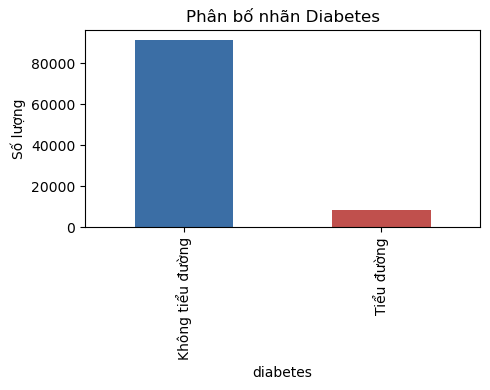

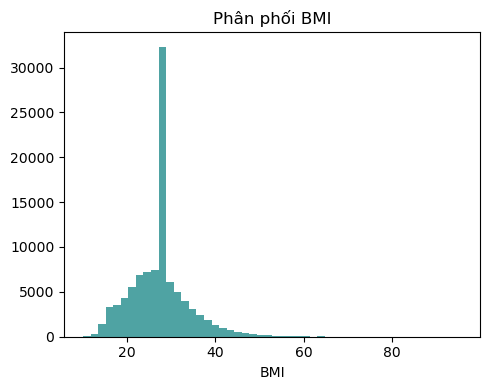

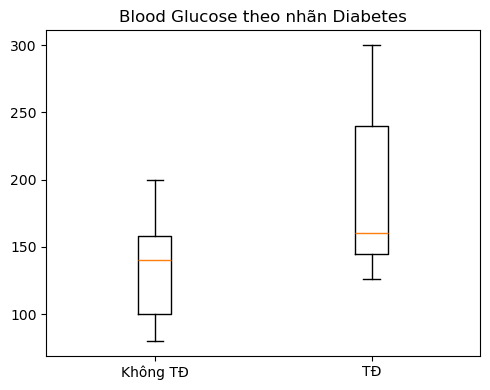

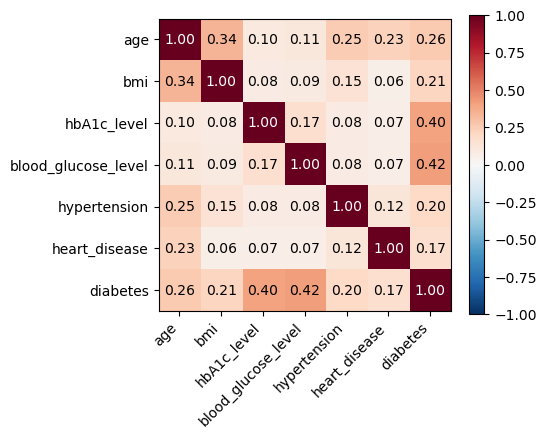

In [4]:
import matplotlib.pyplot as plt

# Hình 4.1 - Phân bố nhãn diabetes
fig, ax = plt.subplots(figsize=(5, 4))
df_diabetes['diabetes'].value_counts().rename(
    {0: 'Không tiểu đường', 1: 'Tiểu đường'}
).plot(kind='bar', color=['#3b6ea5', '#c0504d'], ax=ax)
ax.set_title('Phân bố nhãn Diabetes')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.savefig('d_balance.png')

# Hình 4.2 - Phân phối BMI
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(df_diabetes['bmi'], bins=50, color='#4fa3a3')
ax.set_title('Phân phối BMI')
ax.set_xlabel('BMI')
plt.tight_layout()
plt.savefig('d_bmi_hist.png')

# Hình 4.3 - Boxplot đường huyết theo nhãn
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [
        df_diabetes[df_diabetes.diabetes == 0]['blood_glucose_level'],
        df_diabetes[df_diabetes.diabetes == 1]['blood_glucose_level'],
    ],
    tick_labels=['Không TĐ', 'TĐ'],
)
ax.set_title('Blood Glucose theo nhãn Diabetes')
plt.tight_layout()
plt.savefig('d_glucose_box.png')

# Hình 4.4 - Ma trận tương quan
num_cols = [
    'age',
    'bmi',
    'hbA1c_level',
    'blood_glucose_level',
    'hypertension',
    'heart_disease',
    'diabetes',
]
corr = df_diabetes[num_cols].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)

# Bổ sung vòng lặp hiển thị giá trị tương quan lên từng ô
for i in range(len(num_cols)):
  for j in range(len(num_cols)):
    val = corr.iloc[i, j]
    ax.text(
        j,
        i,
        f'{val:.2f}',
        ha='center',
        va='center',
        color='white' if abs(val) > 0.5 else 'black',
    )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('d_corr_matrix.png')

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
 
# ----- Diabetes -----
num_feats = ['age','bmi','hbA1c_level','blood_glucose_level']
bin_feats = ['hypertension','heart_disease','race:AfricanAmerican','race:Asian',
             'race:Caucasian','race:Hispanic','race:Other']
cat_feats = ['gender','smoking_history']
 
X = df_diabetes[num_feats + bin_feats + cat_feats]
y = df_diabetes['diabetes']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
 
preprocess_diabetes = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_feats),
], remainder='passthrough')
 
print(f'Train: {len(X_train)}  Test: {len(X_test)}')


Train: 79974  Test: 19994


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
 
models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                    class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=15),
}
 
fitted_clf = {}
for name, clf in models_clf.items():
    pipe = Pipeline([('pre', preprocess_diabetes), ('clf', clf)])
    pipe.fit(X_train, y_train)
    fitted_clf[name] = pipe
    print(f'Đã huấn luyện: {name}')


Đã huấn luyện: Logistic Regression
Đã huấn luyện: Decision Tree
Đã huấn luyện: Random Forest
Đã huấn luyện: Gradient Boosting
Đã huấn luyện: K-Nearest Neighbors


In [8]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
 
results_clf = {}
for name, pipe in fitted_clf.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results_clf[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
    }
 
pd.DataFrame(results_clf).T.round(4).sort_values('f1', ascending=False)


,accuracy,precision,recall,f1,roc_auc
Gradient Boosting,0.9726,0.9824,0.6900,0.8106,0.9781
K-Nearest Neighbors,0.9602,0.9748,0.5459,0.6998,0.9407
Random Forest,0.9176,0.5090,0.8835,0.6459,0.9744
Logistic Regression,0.8875,0.4221,0.8771,0.5700,0.9619
Decision Tree,0.8818,0.4125,0.9212,0.5699,0.9726
